# POI Accessibility — Isochrone, Service Area & Equity

**Library:** [`sitex`](../sitex) · **Original, fully-documented version:** [`03-NA02-POI_Accessibility.ipynb`](../documentations/03-NA02-POI_Accessibility.ipynb) · **Companion reader:** [`03-NA-Accessibility_Overview.ipynb`](../documentations/03-NA-Accessibility_Overview.ipynb)

Thin, parameterized version of the POI accessibility workflow. All the numeric logic
lives in `sitex.network.poi_accessibility` (+ shared helpers in
`sitex.network.accessibility_common`); this notebook is the parameters and the calls.

**Two deliberately different methods, on purpose:** the isochrone/service-area maps
(convex hull per facility) answer *"what can this facility reach"*; the H3-grid
accessibility/equity numbers answer *"for every point in the area, what's the walk to
the nearest facility"* — they are not expected to trace the same boundary. See the
original notebook's own Methodology section for the full comparison.

## 1. Install & import

In [1]:
# One-time setup, if `sitex` isn't already installed in this kernel:
# %pip install "sitex[network] @ git+https://github.com/ArchiColab/sitex.git"

import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[network] @ git+https://github.com/ArchiColab/sitex.git"

    from google.colab import drive
    drive.mount("/content/gdrive")

    DATA_DIR = Path("/content/gdrive/MyDrive/Colab_Outputs")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")

    if not (DATA_DIR / "overture").is_dir():
        raise FileNotFoundError(
            f"{DATA_DIR} not found (or incomplete) in your Google Drive. "
            "Before the workshop: download the workshop data zip and unzip it into "
            "My Drive/Colab_Outputs -- see the workshop setup instructions."
        )
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import geopandas as gpd
import pandas as pd

from sitex.core.config import CityConfig
from sitex.core.svg_charts import render_dual_bar_chart_svg
from sitex.network import accessibility_common as ac
from sitex.network import poi_accessibility as pa

## 2. Configuration & inputs

Reads the classified POIs (`01-ARCH-POIsClassification.ipynb`) and enriched buildings
(`01-ARCH-Building_Morphology.ipynb`) — `floor_area_m2 = footprint area × estimated
floor count` is the population/floor-area proxy for the capture metric, which means it
inherits the ARCH module's rule-based height/floor estimates.

In [ ]:
city = CityConfig(
    place_name="Phường Pleiku, Gia Lai, Vietnam",
    local_lat=13.9833,
    local_lon=108.0000,
    slug="phường_pleiku",
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
)

ESSENTIAL_GROUPS = ["Healthcare", "Education", "Daily Needs & Grocery", "Civic & Government"]
TIME_BANDS = [5, 10, 15]
MAX_WALK_TIME = max(TIME_BANDS)
H3_RESOLUTION = 9
CATEGORY_COLORS = {
    "Healthcare": "#e41a1c", "Education": "#377eb8",
    "Daily Needs & Grocery": "#4daf4a", "Civic & Government": "#984ea3",
}

pois = gpd.read_file(city.data_dir / "overture" / f"pois_classified_{city.slug}.geojson").to_crs("EPSG:4326")
essential_pois = pois[pois["functional_group"].isin(ESSENTIAL_GROUPS)].copy()
essential_pois = essential_pois[essential_pois.geometry.type == "Point"].reset_index(drop=True)
print(f"Essential-service POIs: {len(essential_pois)}")
print(essential_pois["functional_group"].value_counts())

buildings = gpd.read_file(city.data_dir / "gdf" / f"{city.slug}_buildings_enriched.gpkg")
buildings["floor_area_m2"] = buildings["area"] * buildings["num_floors_est"].fillna(1)
buildings["centroid"] = buildings.geometry.centroid
print(f"Buildings: {len(buildings):,}")

## 3. Walking network & H3 grid

Constant 4.8 km/h pedestrian pace on every edge — **not** `ox.add_edge_speeds()`,
which imputes driving speeds by highway type (e.g. ~40 km/h on a residential street)
and would make every isochrone below several times too generous.

In [3]:
print("Downloading walkable network...")
G, boundary_poly = ac.build_walk_graph(city.place_name)
print(f"Network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

base_grid = ac.build_h3_grid(boundary_poly, H3_RESOLUTION)
base_grid = ac.assign_origin_nodes(base_grid, G)
print(f"H3 grid (res {H3_RESOLUTION}): {len(base_grid)} hexes")

Network: 2,673 nodes, 6,688 edges
H3 grid (res 9): 217 hexes


## 4. Isochrones, service areas & building capture

One Dijkstra search per facility drives all three: the isochrone (union of every
facility's hull, per time band), the service area (each facility's own hull at the
largest band, kept separate — allowed to overlap), and the buildings/floor-area
captured inside each band.

In [4]:
results = {}
for group in ESSENTIAL_GROUPS:
    subset = essential_pois[essential_pois["functional_group"] == group]
    if subset.empty:
        continue
    print(f"{group}: {len(subset)} facilities...")
    facility_polys = pa.compute_facility_isochrones(G, subset, TIME_BANDS)
    isochrones = pa.union_category_isochrones(facility_polys, TIME_BANDS)
    service_area = pa.extract_service_areas(facility_polys, MAX_WALK_TIME)
    building_capture = pa.capture_buildings(buildings, isochrones, city.local_epsg)
    grid = pa.compute_category_accessibility(G, base_grid, subset, MAX_WALK_TIME)
    results[group] = dict(pois=subset, isochrones=isochrones, service_area=service_area, building_capture=building_capture, grid=grid)
    print(building_capture.round(1).to_string(index=False))

Healthcare: 121 facilities...
 time_min  n_buildings  floor_area_m2  n_buildings_pct  floor_area_pct
        5        10793      3241249.7             50.7            50.4
       10        15676      4658486.7             73.6            72.5
       15        17598      5169499.5             82.7            80.4
Education: 88 facilities...
 time_min  n_buildings  floor_area_m2  n_buildings_pct  floor_area_pct
        5        11351      3350824.3             53.3            52.1
       10        15740      4572216.1             73.9            71.1
       15        17582      5098570.8             82.6            79.3
Daily Needs & Grocery: 78 facilities...
 time_min  n_buildings  floor_area_m2  n_buildings_pct  floor_area_pct
        5        11462      3402030.9             53.8            52.9
       10        16580      4840248.5             77.9            75.3
       15        18096      5282096.4             85.0            82.2
Civic & Government: 38 facilities...
 time_min  n_

## 5. Accessibility & equity summary

In [5]:
summary = pd.DataFrame([
    pa.compute_accessibility_summary(
        group, res["pois"], res["grid"],
        res["building_capture"].set_index("time_min").loc[MAX_WALK_TIME],
        MAX_WALK_TIME,
    )
    for group, res in results.items()
]).round(3)
summary

,category,n_facilities,median_access_min,pct_hexes_15min,pct_buildings_15min,pct_floor_area_15min,gini_access_time
0,Healthcare,121,5.933,59.447,82.670,80.422,0.369
1,Education,88,5.605,53.917,82.595,79.318,0.372
2,Daily Needs & Grocery,78,5.763,58.065,85.010,82.173,0.388
3,Civic & Government,38,7.320,41.014,67.130,66.281,0.344


## 6. Maps & chart

Rendered via folium + hand-built SVG (`sitex.core.svg_charts`), not matplotlib — this
kernel's matplotlib install crashes on any actual figure render, independent of what's
plotted.

In [6]:
combined_map = pa.build_combined_map(results, boundary_poly, CATEGORY_COLORS, MAX_WALK_TIME, default_show=ESSENTIAL_GROUPS[0])
combined_map

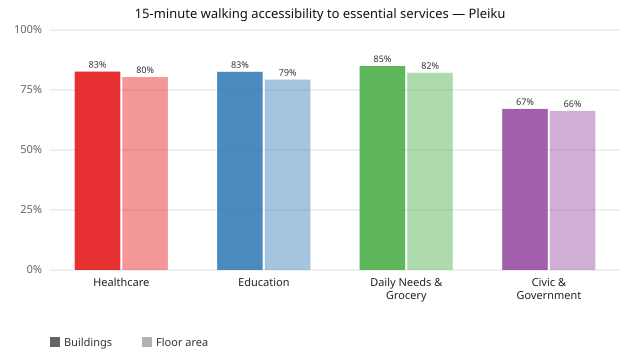

In [7]:
from IPython.display import SVG, display

chart = render_dual_bar_chart_svg(
    labels=summary["category"].tolist(),
    series={
        "Buildings": (summary["pct_buildings_15min"].tolist(), 0.9),
        "Floor area": (summary["pct_floor_area_15min"].tolist(), 0.45),
    },
    colors=CATEGORY_COLORS,
    title=f"{MAX_WALK_TIME}-minute walking accessibility to essential services — Pleiku",
)
display(SVG(chart))

## 7. Interactive — what if a new facility opened here?

The isochrone/service-area/H3 layers above are for the *existing* essential-service
POIs. This section answers a planning question instead: click a candidate site on the
map (CartoDB Positron or Satellite basemap) and the next cell runs the same
isochrone/service-area/H3-grid pipeline from Section 4 for that one point, then folds
it into the chosen category to show the before/after change in walk-time equity —
handy for "what if a clinic opened here?" siting questions. The candidate's point,
isochrones, service area, and the recomputed H3 grid are also saved to `.gpkg` (same
convention as Section 8) so the pick survives beyond this kernel.

In [8]:
NEW_FACILITY_GROUP = "Healthcare"  # change to try siting a candidate in another category

picker_map = pa.build_picker_map(boundary_poly)
print("Click the marker tool (top-left of the map), then click a point on the map below.")
picker_map

Click the marker tool (top-left of the map), then click a point on the map below.


Map(center=[13.996606232744274, 108.03049291070839], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [9]:
point = pa.picked_point(picker_map)

if point is None:
    print("No point picked yet — click the marker tool above, drop a pin, then re-run this cell.")
else:
    lon, lat = point
    print(f"Picked point: lat={lat:.6f}, lon={lon:.6f}")

    baseline = results[NEW_FACILITY_GROUP]
    new_res = pa.evaluate_new_facility(
        G, base_grid, buildings,
        baseline["pois"], baseline["isochrones"], baseline["service_area"],
        NEW_FACILITY_GROUP, "Candidate facility", lon, lat,
        TIME_BANDS, MAX_WALK_TIME, city.local_epsg,
    )

    print(f"\n{NEW_FACILITY_GROUP} — with candidate added:")
    print(pd.Series(new_res["updated_summary"]).round(3).to_string())
    print(f"\n{NEW_FACILITY_GROUP} — baseline (without candidate):")
    print(summary[summary["category"] == NEW_FACILITY_GROUP].iloc[0].round(3).to_string())

    new_facility_map = pa.build_new_facility_map(baseline["grid"], new_res, boundary_poly, CATEGORY_COLORS[NEW_FACILITY_GROUP])
    display(new_facility_map)

    # Export — candidate point, its own isochrones/service area, and the category's
    # H3 grid recomputed with it added, so the pick survives beyond this kernel.
    _tag = NEW_FACILITY_GROUP.lower().replace(" & ", "_").replace(" ", "_")
    gdf_dir = city.data_dir / "gdf"

    new_res["new_poi"].to_crs(epsg=city.local_epsg).to_file(
        gdf_dir / f"poi_candidate_point_{_tag}.gpkg", driver="GPKG",
    )
    new_res["candidate_service_area"].to_crs(epsg=city.local_epsg).to_file(
        gdf_dir / f"poi_candidate_service_area_{_tag}.gpkg", driver="GPKG",
    )

    _iso_rows = [{"time_min": t, "geometry": poly} for t, poly in new_res["candidate_isochrones"].items() if poly is not None]
    if _iso_rows:
        gpd.GeoDataFrame(_iso_rows, crs="EPSG:4326").to_crs(epsg=city.local_epsg).to_file(
            gdf_dir / f"poi_candidate_isochrones_{_tag}.gpkg", driver="GPKG",
        )

    new_res["updated_grid"][["h3_id", "access_time_min", "nearest_poi_name", "geometry"]].to_crs(epsg=city.local_epsg).to_file(
        gdf_dir / f"poi_access_grid_{_tag}_with_candidate.gpkg", driver="GPKG",
    )

    print(f"\nSaved candidate point, isochrones, service area, and updated H3 grid to {gdf_dir}")

No point picked yet — click the marker tool above, drop a pin, then re-run this cell.


---
## 8. Export

In [10]:
combined_map.save(str(city.output_dir / "poi_accessibility_map.html"))
summary.to_csv(city.output_dir / "poi_accessibility_summary.csv", index=False)
print("Saved poi_accessibility_map.html and poi_accessibility_summary.csv")


def _safe_name(group):
    return group.lower().replace(" & ", "_").replace(" ", "_")


for group, res in results.items():
    tag = _safe_name(group)
    grid_export = res["grid"][["h3_id", "access_time_min", "nearest_poi_name", "geometry"]].to_crs(epsg=city.local_epsg)
    grid_export.to_file(city.data_dir / "gdf" / f"poi_access_grid_{tag}.gpkg", driver="GPKG")

    service_export = res["service_area"].to_crs(epsg=city.local_epsg)
    service_export.to_file(city.data_dir / "gdf" / f"poi_service_area_{tag}.gpkg", driver="GPKG")

    iso_rows = [{"time_min": t, "geometry": poly} for t, poly in res["isochrones"].items() if poly is not None]
    if iso_rows:
        iso_export = gpd.GeoDataFrame(iso_rows, crs="EPSG:4326").to_crs(epsg=city.local_epsg)
        iso_export.to_file(city.data_dir / "gdf" / f"poi_isochrones_{tag}.gpkg", driver="GPKG")

print(f"GeoPackages saved to {city.data_dir / 'gdf'}")

Saved poi_accessibility_map.html and poi_accessibility_summary.csv
GeoPackages saved to ..\..\data\gdf


---
## Notes

- **`pa.build_combined_map` fixes a real bug in the original notebook**: its export
  cell (Section 4) saves a `combined_map` variable that is never defined anywhere in
  its own source — confirmed against the live notebook file, not a stale claim. This
  is what that step evidently intended: one map combining isochrones and the H3
  access grid for every category, built from the plotting functions the original
  notebook already defines separately. Per-facility service areas are left out of
  this combined map on purpose — with dozens of facilities per category their hulls
  overlap so heavily the layer is just noise; see Section 7 for where a single
  service-area polygon is actually readable.
- **`height_est`/`num_floors_est`-derived floor area is modelled, not measured** — the
  capture percentages inherit that uncertainty from the ARCH module.
- **Use the exported `.gpkg` files, not GeoJSON**, for any further spatial join — they're
  already reprojected to `city.local_epsg`.
- **Section 7's interactive picker replaces the original notebook's `leafmap` "pick
  your own point" sidebar** (its own Section 2) with a version that also folds the
  candidate into the category's H3 grid — a genuine before/after siting comparison,
  not just a standalone service-area polygon — using `pa.build_picker_map`,
  `pa.picked_point`, `pa.evaluate_new_facility`, and `pa.build_new_facility_map`.
  It exports its own set of `.gpkg` files the moment a point is picked
  (`poi_candidate_point_*`, `poi_candidate_service_area_*`,
  `poi_candidate_isochrones_*`, `poi_access_grid_*_with_candidate`) — independent of
  Section 8's export cell, since a pick may happen (or change) after Section 8 has
  already run.